In [1]:
# Bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
from polars import col as c
import numpy as np
import math
from scipy.optimize import curve_fit
import seaborn as sns
%matplotlib inline

In [77]:
input_path = '/home/orfei/mestrado/progs/corsika/corsika-76900/run/dat/DAT4011414'
output_path = '/home/orfei/mestrado/progs/lateral_distribution/DAT4561514_tratado'

In [45]:
exclude = [
  'EVTH', 'RUNE', 'EVTE'
]

(
  pl.scan_csv(
    source = input_path,
    skip_rows = 6,
    has_header = False,
    null_values = exclude
  ).with_columns(
    c('column_1')
    .str.replace_all("  ", " ")
    .str.split(' ')
    .list.to_struct(
      n_field_strategy = 'max_width',
      upper_bound = 7
    )
  ).unnest(
    'column_1'
  ).select(
    ['field_0', 'field_4', 'field_5']
  ).rename(
    {
      'field_0': 'm',
      'field_4': 'x',
      'field_5': 'y'
    }
  ).cast(pl.Float64,strict=False).filter(
    c('m').is_between(2000, 7000)
  ).with_columns(
    ((c('x') ** 2 + c('y') ** 2) ** 0.5).alias('r')
  )
).sink_csv(output_path, separator = '\t', has_header=False,batch_size= 2**18)

#print(lf.tail().collect(streaming = True))


In [78]:
tamanho = len(pl.scan_csv(output_path).collect(streaming=True))
print(tamanho)
t2 = math.sqrt(tamanho)
t2_int = int(t2)
dr = 1000000/t2

20976079


In [32]:
df = pl.read_csv(output_path, separator="\t", has_header= False)
df2 = df.with_columns(
    (1/(pl.col('column_4')*100*2*math.pi*dr)).alias('peso')
)
df2.head()

column_1,column_2,column_3,column_4,peso
f64,f64,f64,f64,f64
3991.0,16767.8,69877.3,71860.950259,1.4791e-11
6541.0,-79554.0,80594.9,113244.765098,9.3859e-12
6551.0,-5889.71,40737.7,41161.25466,2.5823e-11
5541.0,793.792,-9184.48,9218.718925,1.1530e-10
6541.0,25756.3,7598.02,26853.619823,3.9582e-11


[None]

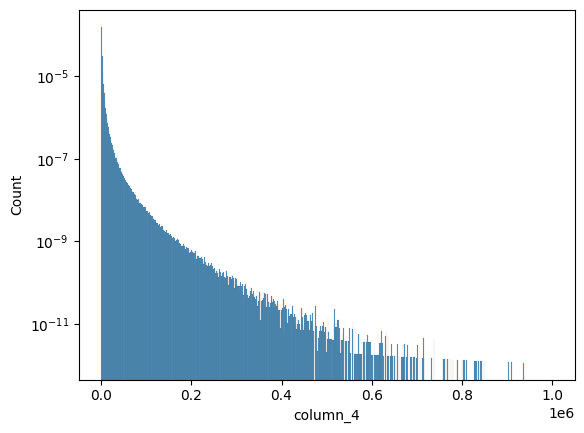

In [33]:
sns.histplot(data = df2, x= 'column_4', weights= 'peso', bins = t2_int, binrange=(0,1000000)).set(yscale = 'log')

In [34]:
def f_model(x, c, a, b, r0):
    return ((c/r0**2)*(x/r0)**(-a)*(1+x/r0)**(-b))

In [35]:
df2 = df2.with_columns(
    f_model(df2["column_4"], 300,-0.1,3.5,10000).alias('model')
) 
df2.head(8)

column_1,column_2,column_3,column_4,peso,model
f64,f64,f64,f64,f64,f64
3991.0,16767.8,69877.3,71860.950259,1.4791e-11,2.3281e-9
6541.0,-79554.0,80594.9,113244.765098,9.3859e-12,5.8188e-10
6551.0,-5889.71,40737.7,41161.25466,2.5823e-11,1.1410e-8
5541.0,793.792,-9184.48,9218.718925,1.1530e-10,3.0238e-7
6541.0,25756.3,7598.02,26853.619823,3.9582e-11,3.4462e-8
6541.0,-43251.0,-8241.0,44029.116298,2.4141e-11,9.4907e-9
6551.0,-8527.47,14494.1,16816.559678,6.3206e-11,1.0007e-7
5551.0,-13908.6,1739.01,14016.893727,7.5831e-11,1.4454e-7


<AxesSubplot: xlabel='column_4', ylabel='Count'>

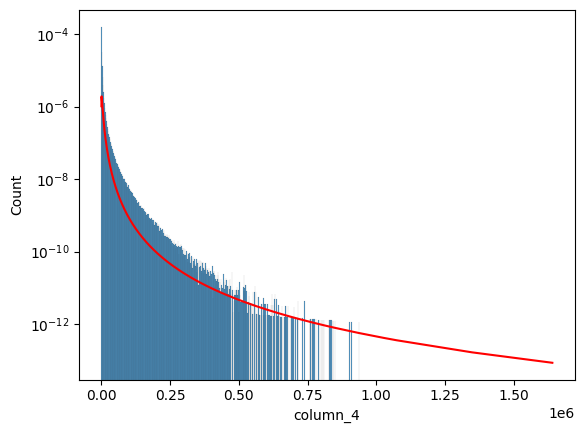

In [36]:
fig, ax = plt.subplots()
sns.histplot(data = df2, x= 'column_4', weights= 'peso', bins = t2_int, binrange=(0,1000000),ax=ax).set(yscale = 'log')
sns.lineplot(data=df2, x= 'column_4', y='model',color = 'r' ,ax=ax)


In [7]:
tupla = np.histogram(df2['column_4'],bins =t2_int, range = (0,1000000), weights=df2['peso'])
y,x = tupla
#df2.with_columns(
#    pl.from_numpy(y[0])
#).head()
x2 = np.delete(x,-1)
#del (x[-1])
print((x2[-1]))




994318.1818181819


In [8]:
popt, pcov = curve_fit(
    f=f_model,       
    xdata=x2,   
    ydata=y,   
    p0=(300,-0.1,3.5,10000)      
    #sigma=df["Dy"]   
)

/tmp/ipykernel_41515/341787350.py:2: RuntimeWarning: divide by zero encountered in power
  return ((c/r0**2)*(x/r0)**(-a)*(1+x/r0)**(-b))


In [35]:
print(popt)

[ 10.91125536  -4.35463074   6.3465627  651.83823232]


In [9]:
c_opt, a_opt, b_opt, r0_opt = popt
print("c = ", c_opt)
print("a = ", a_opt)
print("b = ", b_opt)
print("r0 = ", r0_opt)

c =  94.28152106172514
a =  -0.0007307514187490309
b =  3.470869712154064
r0 =  11909.462279794388


In [10]:
perr = np.sqrt(np.diag(pcov))
Dc, Da, Db, Dr0 = perr
print(perr)

[3.77068891e+03 1.39271715e+02 4.39863612e+01 1.86294239e+06]


In [11]:
df2 = df2.with_columns(
    f_model(df2["column_4"], c_opt, a_opt, b_opt, r0_opt).alias('model')
) 
df2.head(8)

column_1,column_2,column_3,column_4,peso,model
f64,f64,f64,f64,f64,f64
5561.0,294838.0,-154574.0,332900.236888,8.4602e-13,5.6282e-12
6561.0,-41217.7,24409.2,47903.108855,5.8794e-12,2.4567e-9
5541.0,-34414.9,20415.9,40014.92615,7.0384e-12,4.0131e-9
5541.0,-10823.0,-19879.1,22634.397403,1.2443e-11,1.6506e-8
5541.0,-121212.0,21735.4,123145.347282,2.2871e-12,1.4553e-10
2991.0,-177464.0,32565.0,180427.13355,1.5610e-12,4.2668e-11
3991.0,-177541.0,33254.9,180628.610843,1.5592e-12,4.2514e-11
3991.0,-177275.0,33096.2,180337.971818,1.5617e-12,4.2737e-11


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


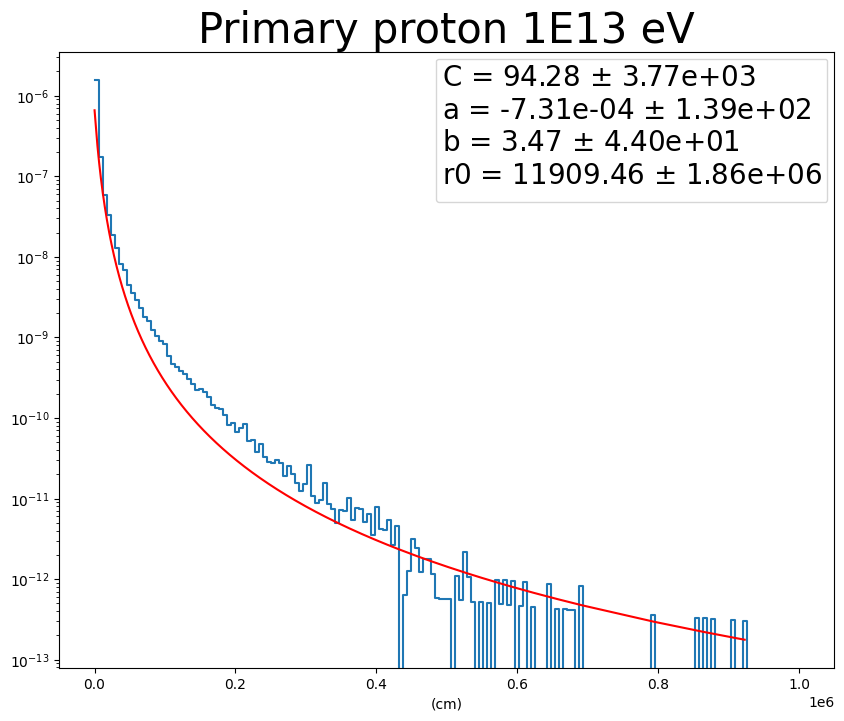

In [27]:
fig, ax = plt.subplots(figsize = (10,8),facecolor = 'white')
sns.histplot(data = df2, x= 'column_4', weights= 'peso', bins = t2_int, fill = False, element= 'step',
              binrange=(0,1000000),ax=ax).set(yscale = 'log')
sns.lineplot(data=df2, x= 'column_4', y='model',color = 'r' ,ax=ax)

ax.set_facecolor('white')
ax.set_title('Primary proton 1E13 eV',fontdict={'fontsize': 30})
ax.set_xlabel("(cm)")
ax.set_ylabel("")
ax.legend(title = 'C = {:.2f} $\pm$ {:.2e}\na = {:.2e} $\pm$ {:.2e}\nb = {:.2f} $\pm$ {:.2e}\nr0 = {:.2f} $\pm$ {:.2e}'
          .format(c_opt,Dc,a_opt,Da,b_opt,Db,r0_opt,Dr0),
          title_fontsize = 20,facecolor = 'white')
ax.grid(visible= False)
plt.savefig('DAT401131_fit.png')